Importing the Dependencies 

In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Perfroming EDA (Exploritary Data Analysis)

In [5]:
#loading the dataset to as pandas dataset. 
wine_dataset = pd.read_csv('winequality-red.csv')

In [6]:
#fetching the information about our dataset. 
wine_dataset.shape

(1599, 12)

In [7]:
wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
wine_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [9]:
#checking is there are any null values present in our dataset,
wine_dataset.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
#understanding the statistical measures of your dataset
wine_dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Data Visualizatoin 

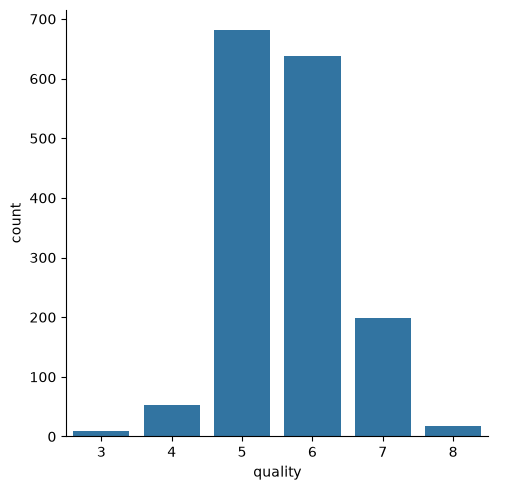

In [11]:
#checking the number of values for each quality 
sns.catplot(x='quality', data=wine_dataset, kind='count')

<Axes: xlabel='quality', ylabel='volatile acidity'>

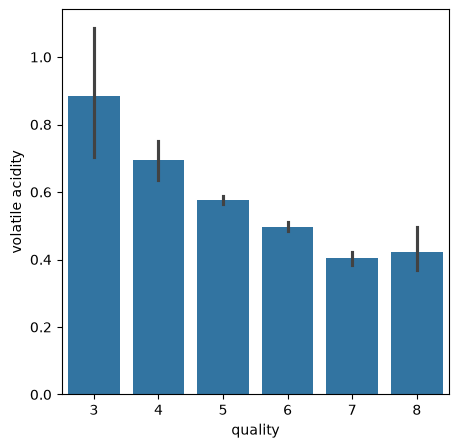

In [12]:
#volatile acidity vs quality
plot = plt.figure(figsize=(5,5))
sns.barplot(x='quality', y='volatile acidity', data=wine_dataset)

#after analysing the below plot, we can come to the conslusion that 'volatile acidity' and the 'quality' are inversely propotional.  
#The quality of the wine is good when the volatile acidity is around 0.4 

<Axes: xlabel='quality', ylabel='citric acid'>

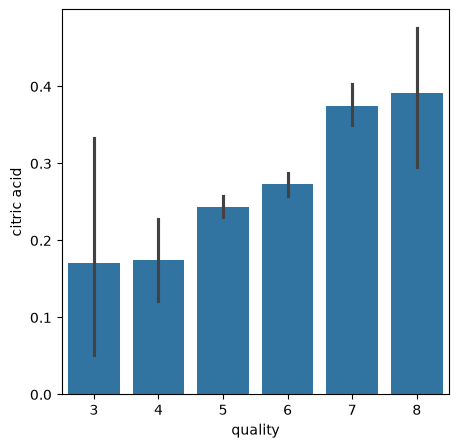

In [13]:
#Comparing the cetric acid and quality of the wine.
plot = plt.figure(figsize=(5,5))
sns.barplot(x='quality', y='citric acid', data=wine_dataset)

#here we analize a different trend. if the citric acid content is more content of the citric acid then the quality of the wine is also good. (this is directly propotional to each other)

<Axes: xlabel='quality', ylabel='residual sugar'>

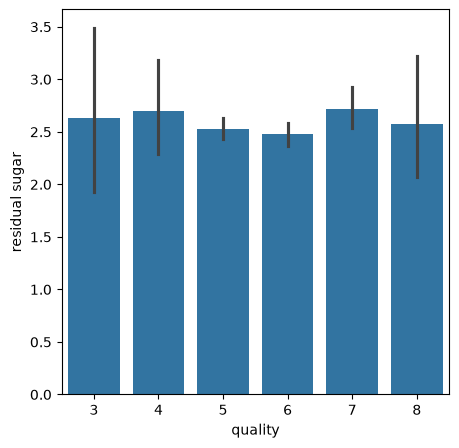

In [14]:
#comparing the residual sugar and quality of the wine, 
plot = plt.figure(figsize=(5,5))
sns.barplot(x='quality', y='residual sugar', data=wine_dataset)

#here we see that the residual sugar is inversely propotional to the quality of the wine. The quality of the wine is good when the residual sugar is around 2.5

In [15]:
#finding the corelation between the quality column to all other columns in the dataset. 
correlation = wine_dataset.corr()

<Axes: >

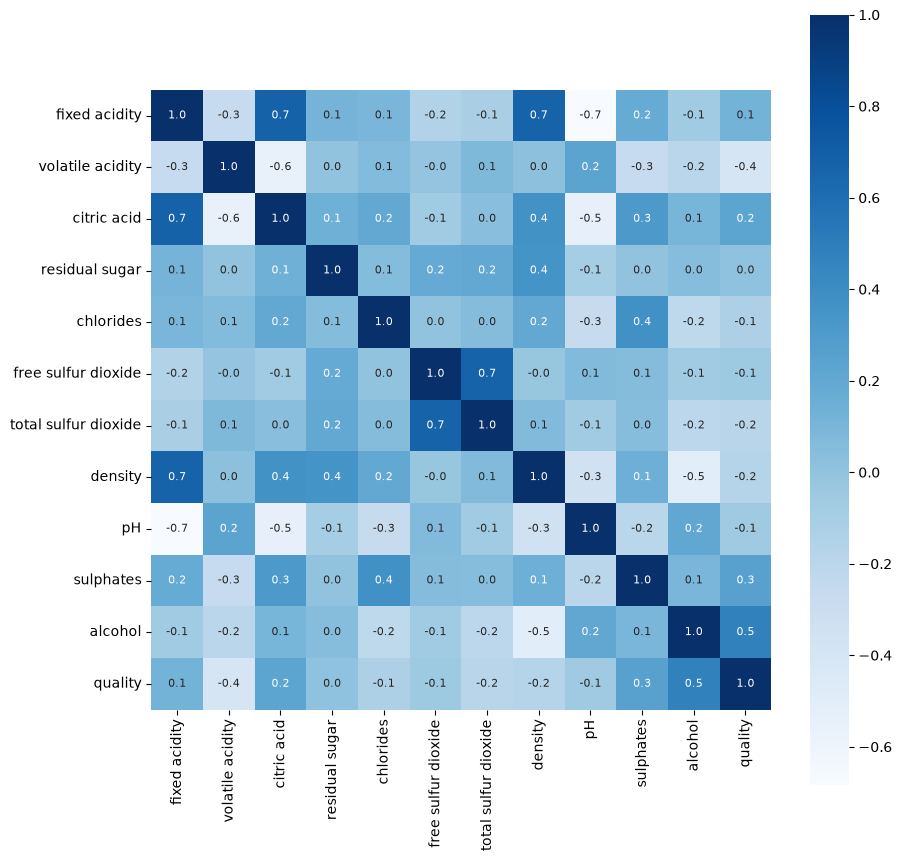

In [16]:
#constructing the heat map to understand the corellation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

Data Preprocessing

In [18]:
#seperate the data and lables 
X = wine_dataset.drop('quality',axis=1)
#now insted of haveing 6 classes of quality, we are converting into 2 sets, good quality and bad quality. this is called as binarising the quality. 
Y = wine_dataset['quality'].apply(lambda y_value:1 if y_value>=7 else 0)
print(Y)

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: int64


Spliting The Data and Model Training

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)
#Model Training : Random Forest Classifier
model = RandomForestClassifier()
model.fit(X_train, Y_train) 
#evulating our model to understand how well our model is evaluating the data [using accuracy score]
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy:' , test_data_accuracy)

Accuracy: 0.91875


For understanding 'Random Forest Classifier' :
    * it is an ensemble model. Ensemble models are those that uses more than two or three models in combination for a prediction 
    * our Randome Foreest Classifier model is an ensemble model of decision treee. 

Building a Predective System

In [23]:
input_data = (7.4, 0.7, 0, 1.9, 0.076, 11, 34, 0.9978, 3.51, 0.56, 9.4)
#converting the input data into a numpy array
input_data_as_numpy_array = np.asarray(input_data)
#reshaping the numpy array as we are predicting the lable for only one instance 
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1) 
prediction = model.predict(input_data_reshaped)
print(prediction)
if (prediction[0]==1):
    print('Good Quality Wine')
else:
    print('Bad Quality Wine')

[0]
Bad Quality Wine


C:\Users\Purvi Krishna\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
